# BMIF 802 - Lab 6: Classification Models

In this lab, you will use a real medical dataset to build and compare three classification algorithms:

- k-nearest neighbours (k-NN)
- decision tree
- random forest

## Learning objectives

By the end of the lab, you should be able to:

- prepare mixed numeric and categorical data for classification;
- avoid target leakage and basic preprocessing leakage;
- create stratified training and testing sets;
- explain why scaling is important for k-NN;
- train and evaluate k-NN, decision tree, and random forest classifiers;
- use 5-fold cross-validation to compare models;
- identify possible overfitting;
- discuss accuracy, interpretability, fairness, trust, and clinical limitations.

## 1. Setup

Run the import cell below. The remaining code cells are intentionally empty.

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

proj_dir = Path.cwd().resolve()
line_break = "\n-----------------------\n"

## 2. Load and inspect the data

The dataset is stored at `data/heart_disease_cleveland.csv`.

1. Read the CSV into a pandas DataFrame.
2. Tell pandas that `?` represents a missing value when the file is loaded.
3. Display the first several rows.
4. Display the number of rows and columns.
5. Inspect the data types.
6. Count missing values in every column.
7. Check for fully duplicated rows.
8. Display the frequency of each value in the original `num` target column.

Do not replace, drop, or transform anything yet. First make sure you understand the raw data.

In [32]:
# Read the CSV into a DataFrame.
data_dir = proj_dir / "data" / "heart_disease_cleveland.csv"
pt_data_df = pd.read_csv(data_dir)

# Convert all instances of "?" to a missing value.
pt_data_df = pt_data_df.replace("?", pd.NA)

# Display the first several rows.
print(pt_data_df.head(3))
print(line_break)

# Print the number of rows and columns.
print(pt_data_df.shape)
print(line_break)

# Inspect the data types.
print(pt_data_df.dtypes)
print(line_break)

# Count the missing values in every column.
nan_count = pt_data_df.isna().sum()
print(nan_count[nan_count > 0]) # 4 in "ca" and 2 in "thal"
print(line_break)

# Check for fully duplicated rows.
num_duplicates = pt_data_df.duplicated().sum()
print(f"Number of duplicated rows: {num_duplicates}") # No duplicated rows.
print(line_break)

# Display the frequency of each value in the num column.
print(pt_data_df["num"].value_counts())

    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   

   slope   ca thal  num  
0    3.0  0.0  6.0    0  
1    2.0  3.0  3.0    2  
2    2.0  2.0  7.0    1  

-----------------------

(303, 14)

-----------------------

age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca              str
thal            str
num           int64
dtype: object

-----------------------

ca      4
thal    2
dtype: int64

-----------------------

Number of duplicated rows: 0

-----------------------

num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


## 3. Understand the features and create the target

Read `DATASET_DESCRIPTION.txt` before continuing.

The original `num` column uses `0` for no heart disease and values `1` through `4` for heart disease being present. For the main lab, convert this into a binary classification problem.

1. Create a new column named `heart_disease`.
2. Assign `0` when `num` is `0`.
3. Assign `1` when `num` is greater than `0`.
4. Display the number of records in each new class.
5. Create a bar chart of the new target distribution.
6. Create `X` containing the predictor columns and `y` containing `heart_disease`.
7. Remove both `num` and `heart_disease` from `X`.

**Why should you remove `num`?**

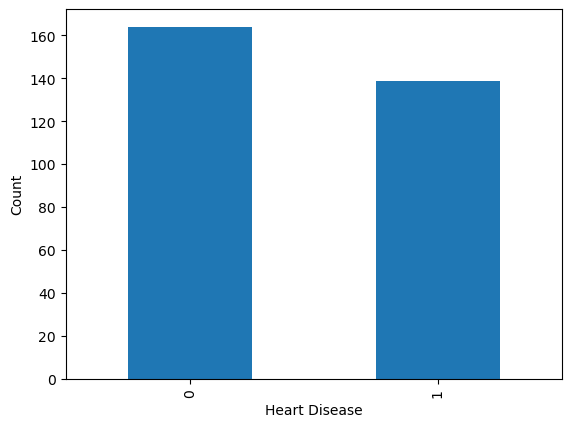

In [37]:
# Create a new column named heart_disease.
pt_data_df["heart_disease"] = (pt_data_df["num"] > 0).astype(int)

# Create a bar chart of the new target distribution.
pt_data_df["heart_disease"].value_counts().plot(kind = "bar")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()


In [40]:
# Create X containing the predictor columns.
X = pt_data_df.drop(columns = ["num", "heart_disease"])

# Create Y containing heart disease.
y = pt_data_df[["heart_disease"]]

### Dataset interpretation

In your own words, briefly describe:

- what one row represents;
- what the model will predict;
- which predictors are numeric measurements;
- which predictors are category codes;
- why this is a supervised learning problem.

**Your notes:**

One row represents a patient.

The model will use predictor columns in a supervised ML classification problem to predict if patients do or do not have heart disease.

The numeric predictors are:
- age
- trestbps
- chol
- thalach
- oldpeak
- ca

The categorical predictors are:
- sex (n)
- cp (o)
- fbs (n)
- restecg (o)
- exang (n)
- slope (n)
- thal (o)

This is a supervised learning problem as we know in advance which patients have CVD.

## 4. Create training and testing sets

Split `X` and `y` before performing any preprocessing step that learns a value from the data.

1. Use 80% of the records for training and 20% for testing.
2. Set `random_state=42` so that everyone obtains the same split.
3. Use `stratify=y` so that both sets have similar class proportions.
4. Display the shapes of all four objects.
5. Compare the class proportions in `y_train` and `y_test`.

**The testing set should now be treated as unseen data. Do not use it to select an imputation value, scaling value, or model hyperparameter.**

## 5. Preprocess the predictor data

Create copies of the training and testing predictor DataFrames before changing them.

### 5.1 Handle missing values

The expected missing columns are `ca` and `thal`.

For each of these columns:

1. Find the most common non-missing value using the **training set only**.
2. Use that training-set value to fill missing entries in both the training and testing sets.
3. Check that neither set contains missing values afterward.

A mode is reasonable here because `thal` is categorical and `ca` is a small discrete count.

### 5.2 Transform categorical predictors

The following columns contain category labels stored as numbers:

- `cp`
- `restecg`
- `slope`
- `thal`

One-hot encode these columns. Do not one-hot encode the target.

To keep training and testing columns identical:

1. Apply the categorical transformation to the training and testing DataFrames.
2. Reindex the testing DataFrame so that it has the same columns, in the same order, as the transformed training DataFrame.
3. Fill any column introduced during reindexing with `0`.

The binary columns `sex`, `fbs`, and `exang` may remain coded as `0` and `1`.

### 5.3 Verify the result

Display:

- the transformed training shape;
- the transformed testing shape;
- the full list of predictor columns;
- the total number of missing values in each set.

Both sets must have the same number and order of columns before a model is trained.

## 6. Establish a baseline

A classifier should be compared with a simple baseline.

1. Find the most common class in `y_train`.
2. Pretend that every testing record is assigned that class.
3. Calculate the resulting testing accuracy.

A useful model should generally perform better than this majority-class baseline.

## 7. k-Nearest Neighbours

k-NN predicts a new record using nearby training records. Because distance is central to the algorithm, the scale of each predictor matters.

### 7.1 k-NN without scaling

1. Create a k-NN classifier
2. Fit it to the transformed but unscaled training predictors.
3. Calculate training accuracy.
4. Calculate testing accuracy.
5. Record the results.

### 7.2 Standardize the predictors

1. Create a `StandardScaler`.
2. Fit the scaler using the training predictors only.
3. Use that fitted scaler to transform **both the training and testing predictors**.
4. Confirm that the transformed arrays have the expected shapes.
5. Fit a new k-NN model using the standardized training predictors.
6. Calculate training and testing accuracy again.
7. Compare the standardized result with the unscaled result.

### Scaling observation

How much did standardization change the k-NN testing accuracy? Explain why predictors measured in units such as cholesterol, blood pressure, age, and binary codes can cause problems when their original scales are used directly.

**Your answer:**

### 7.3 Choose a value of k using cross-validation

Use only the standardized **training** predictors for this step.

1. Create a stratified 5-fold cross-validation object
2. Test odd values of `k` from 1 through 25.
3. For each value, calculate the five validation accuracies.
4. Store the mean and standard deviation.
5. Plot mean cross-validation accuracy against `k`.
6. Identify the `k` with the highest mean accuracy.
7. Fit a final k-NN classifier with that value using all standardized training data.
8. Calculate its training and testing accuracy.

## 8. Decision Tree

Decision trees split the feature space into regions using a sequence of rules.

1. Create a `DecisionTreeClassifier` with no depth limit
2. Fit it using the transformed, **unscaled** training predictors.
3. Calculate training and testing accuracy.
4. Compare the two values. A very large gap may indicate overfitting.
5. Plot the first few levels of the tree using `plot_tree`.
6. Include feature names and class names in the visualization.
7. Limit the plotted depth so that the figure remains readable; this changes only the visualization, not the fitted tree.

## 8.1 Choose tree depth value

Try different values of tree depth and find the best one based on the training and testing accuracies

### Decision-tree observation

- When does the tree appear to overfit?
- Is a single decision tree easier to explain than k-NN or a random forest?
- Why can a small change in the training data produce a different tree?

**Your answer:**

## 9. Random Forest

A random forest combines many decision trees. Each tree is trained on a different sample of records and considers a random subset of features when splitting.

1. Create a `RandomForestClassifier`
2. Fit it using the transformed, unscaled training predictors.
3. Calculate training and testing accuracy.
4. Compare its testing accuracy with the single decision tree.
5. Explain why combining many varied trees can be more stable than relying on one tree.

## 10. Compare the classifiers

Use the selected k-NN, decision tree, and random forest models.

1. Calculate 5-fold cross-validation accuracy on the training data for each model.
   - Use standardized predictors for k-NN.
   - Use unscaled predictors for the tree models.
2. Create a results table with:
   - model name;
   - training accuracy;
   - testing accuracy;
   - mean cross-validation accuracy;
   - cross-validation standard deviation.
3. Create a bar chart of mean cross-validation accuracy with error bars showing one standard deviation.
4. Compare each model with the majority-class baseline.
   

### Model comparison questions

1. Which model had the highest testing accuracy?
2. Which model had the highest mean cross-validation accuracy?
3. Which model would be easiest to explain to a clinician?
4. Why should you avoid declaring one algorithm universally best based on this single dataset and split?

**Your answers:**

1. 
2. 
3. 
4. 

## 11. Optional: inspect prediction errors

Accuracy reports how many predictions were correct, but it does not show the types of mistakes.

Create a confusion matrix for each final model using the testing set. In this binary target:

- a false positive predicts heart disease when the label is 0;
- a false negative predicts no heart disease when the label is 1.

Discuss why these two errors may have different consequences in a medical setting.

## Bonus tasks

- Try different parameters of the models and see how they effect the accuracy
- Plot the random forest's feature importances and investigate what the leading features measure.
- Repeat the problem as a five-class classification task using the original `num` values, see if the models accruacies change.